# 📚 Próximos Passos Essenciais para Ciência de Dados e Machine Learning

## O que você já domina:
✅ Estatística descritiva (média, mediana, moda, variância, desvio padrão)  
✅ Medidas de forma (assimetria, curtose)  
✅ Correlação (Pearson, Spearman)  
✅ Visualizações básicas (histograma, barras, scatter, boxplot, linhas)  
✅ Manipulação básica de DataFrames com Pandas  
✅ Trabalho com datas

## O que você PRECISA aprender agora:


## 1. Limpeza e Preparação de Dados (Data Cleaning)

### 1.1 Detecção e Tratamento de Valores Ausentes (Missing Values)


In [19]:
# Criar DataFrame com valores ausentes para demonstração
import numpy as np
import pandas as pd

df_exemplo = pd.DataFrame({
    'idade': [25, 30, None, 35, 40, None, 50],
    'salario': [5000, 6000, 7000, None, 8000, 9000, None],
    'experiencia': [2, 5, None, 10, 15, 20, 25]
})

print("DataFrame com valores ausentes:")
print(df_exemplo)
print("\n" + "="*50)
print("Verificar valores ausentes:")
print(df_exemplo.isnull().sum())
print("\n" + "="*50)
print("Percentual de valores ausentes:")
print(df_exemplo.isnull().sum() / len(df_exemplo) * 100)


DataFrame com valores ausentes:
   idade  salario  experiencia
0   25.0   5000.0          2.0
1   30.0   6000.0          5.0
2    NaN   7000.0          NaN
3   35.0      NaN         10.0
4   40.0   8000.0         15.0
5    NaN   9000.0         20.0
6   50.0      NaN         25.0

Verificar valores ausentes:
idade          2
salario        2
experiencia    1
dtype: int64

Percentual de valores ausentes:
idade          28.571429
salario        28.571429
experiencia    14.285714
dtype: float64


In [4]:
# Estratégias para tratar valores ausentes:

# 1. Remover linhas com valores ausentes
df_sem_nulos = df_exemplo.dropna()
print("Removendo todas as linhas com NaN:")
print(df_sem_nulos)

# 2. Preencher com média (para variáveis numéricas)
df_preenchido_media = df_exemplo.copy()
df_preenchido_media['idade'].fillna(df_preenchido_media['idade'].mean(), inplace=True)
df_preenchido_media['salario'].fillna(df_preenchido_media['salario'].mean(), inplace=True)
print("\nPreenchendo com média:")
print(df_preenchido_media)

# 3. Preencher com mediana (mais robusto a outliers)
df_preenchido_mediana = df_exemplo.copy()
df_preenchido_mediana['idade'].fillna(df_preenchido_mediana['idade'].median(), inplace=True)
print("\nPreenchendo com mediana:")
print(df_preenchido_mediana)

# 4. Preencher com valor específico
df_preenchido_zero = df_exemplo.copy()
df_preenchido_zero.fillna(0, inplace=True)
print("\nPreenchendo com zero:")
print(df_preenchido_zero)


Removendo todas as linhas com NaN:
   idade  salario  experiencia
0   25.0   5000.0          2.0
1   30.0   6000.0          5.0
4   40.0   8000.0         15.0

Preenchendo com média:
   idade  salario  experiencia
0   25.0   5000.0          2.0
1   30.0   6000.0          5.0
2   36.0   7000.0          NaN
3   35.0   7000.0         10.0
4   40.0   8000.0         15.0
5   36.0   9000.0         20.0
6   50.0   7000.0         25.0

Preenchendo com mediana:
   idade  salario  experiencia
0   25.0   5000.0          2.0
1   30.0   6000.0          5.0
2   35.0   7000.0          NaN
3   35.0      NaN         10.0
4   40.0   8000.0         15.0
5   35.0   9000.0         20.0
6   50.0      NaN         25.0

Preenchendo com zero:
   idade  salario  experiencia
0   25.0   5000.0          2.0
1   30.0   6000.0          5.0
2    0.0   7000.0          0.0
3   35.0      0.0         10.0
4   40.0   8000.0         15.0
5    0.0   9000.0         20.0
6   50.0      0.0         25.0


C:\Users\gabriel.lima\AppData\Local\Temp\ipykernel_15940\2042445099.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_preenchido_media['idade'].fillna(df_preenchido_media['idade'].mean(), inplace=True)
C:\Users\gabriel.lima\AppData\Local\Temp\ipykernel_15940\2042445099.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

### 1.2 Detecção e Tratamento de Outliers (Valores Extremos)


In [5]:
# Criar dados com outliers
dados_com_outliers = pd.DataFrame({
    'salario': [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 50000]  # 50000 é um outlier
})

print("Dados com outlier:")
print(dados_com_outliers)
print("\nEstatísticas:")
print(dados_com_outliers.describe())

# Método 1: Identificar outliers usando IQR (Interquartile Range)
Q1 = dados_com_outliers['salario'].quantile(0.25)
Q3 = dados_com_outliers['salario'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\nLimite inferior: {limite_inferior}")
print(f"Limite superior: {limite_superior}")

outliers = dados_com_outliers[(dados_com_outliers['salario'] < limite_inferior) | 
                               (dados_com_outliers['salario'] > limite_superior)]
print(f"\nOutliers encontrados: {len(outliers)}")
print(outliers)


Dados com outlier:
   salario
0     3000
1     3500
2     4000
3     4500
4     5000
5     5500
6     6000
7     6500
8     7000
9    50000

Estatísticas:
            salario
count     10.000000
mean    9500.000000
std    14288.690166
min     3000.000000
25%     4125.000000
50%     5250.000000
75%     6375.000000
max    50000.000000

Limite inferior: 750.0
Limite superior: 9750.0

Outliers encontrados: 1
   salario
9    50000


In [6]:
# Tratamento de outliers:

# 1. Remover outliers
dados_sem_outliers = dados_com_outliers[(dados_com_outliers['salario'] >= limite_inferior) & 
                                        (dados_com_outliers['salario'] <= limite_superior)]
print("Dados sem outliers:")
print(dados_sem_outliers)

# 2. Substituir outliers pelo limite (capping)
dados_capped = dados_com_outliers.copy()
dados_capped.loc[dados_capped['salario'] > limite_superior, 'salario'] = limite_superior
dados_capped.loc[dados_capped['salario'] < limite_inferior, 'salario'] = limite_inferior
print("\nDados com capping (limitados aos extremos):")
print(dados_capped)


Dados sem outliers:
   salario
0     3000
1     3500
2     4000
3     4500
4     5000
5     5500
6     6000
7     6500
8     7000

Dados com capping (limitados aos extremos):
   salario
0     3000
1     3500
2     4000
3     4500
4     5000
5     5500
6     6000
7     6500
8     7000
9     9750


## 2. Bibliotecas Essenciais para ML

### 2.1 NumPy - Operações Numéricas


In [7]:
# NumPy é fundamental para operações matemáticas eficientes
import numpy as np

# Criar arrays
arr1 = np.array([1, 2, 3, 4, 5])
arr2 = np.array([10, 20, 30, 40, 50])

print("Array 1:", arr1)
print("Array 2:", arr2)
print("\nSoma:", arr1 + arr2)
print("Multiplicação:", arr1 * 2)
print("Média:", np.mean(arr1))
print("Desvio padrão:", np.std(arr1))

# Operações úteis
print("\nArray de zeros:", np.zeros(5))
print("Array de uns:", np.ones(5))
print("Array sequencial:", np.arange(0, 10, 2))
print("Array com valores aleatórios:", np.random.rand(5))


Array 1: [1 2 3 4 5]
Array 2: [10 20 30 40 50]

Soma: [11 22 33 44 55]
Multiplicação: [ 2  4  6  8 10]
Média: 3.0
Desvio padrão: 1.4142135623730951

Array de zeros: [0. 0. 0. 0. 0.]
Array de uns: [1. 1. 1. 1. 1.]
Array sequencial: [0 2 4 6 8]
Array com valores aleatórios: [0.01603076 0.93276735 0.04387662 0.07276557 0.93491529]


### 2.2 Matplotlib e Seaborn - Visualizações Avançadas


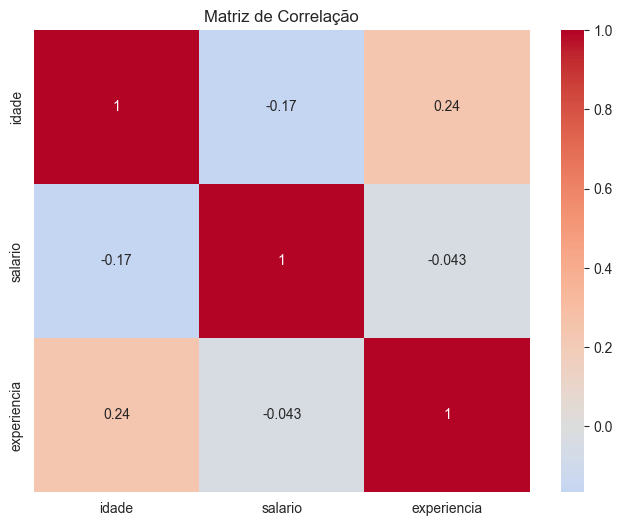

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Criar dados de exemplo
dados_ml = pd.DataFrame({
    'idade': np.random.randint(20, 60, 100),
    'salario': np.random.randint(3000, 10000, 100),
    'experiencia': np.random.randint(0, 20, 100),
    'categoria': np.random.choice(['A', 'B', 'C'], 100)
})

# Heatmap de correlação (muito útil!)
plt.figure(figsize=(8, 6))
sns.heatmap(dados_ml[['idade', 'salario', 'experiencia']].corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()


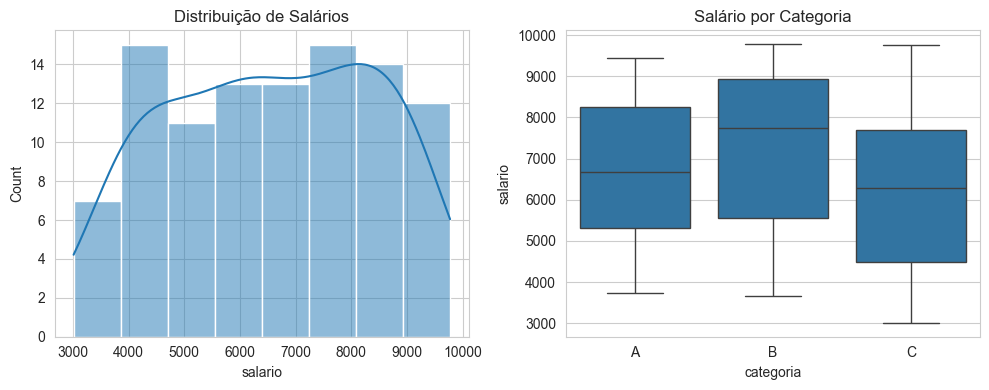

In [9]:
# Pairplot - visualiza relações entre todas as variáveis
# sns.pairplot(dados_ml[['idade', 'salario', 'experiencia']])
# plt.show()

# Gráfico de distribuição com KDE (Kernel Density Estimation)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(dados_ml['salario'], kde=True)
plt.title('Distribuição de Salários')

plt.subplot(1, 2, 2)
sns.boxplot(data=dados_ml, x='categoria', y='salario')
plt.title('Salário por Categoria')
plt.tight_layout()
plt.show()


## 3. Feature Engineering (Engenharia de Features)

### 3.1 Codificação de Variáveis Categóricas


In [1]:
# Dados categóricos precisam ser convertidos para números
df_categorias = pd.DataFrame({
    'cidade': ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'São Paulo', 'Rio de Janeiro'],
    'tipo': ['A', 'B', 'A', 'C', 'B'],
    'valor': [100, 200, 150, 300, 250]
})

print("Dados originais:")
print(df_categorias)

# One-Hot Encoding (cria colunas binárias para cada categoria)
df_onehot = pd.get_dummies(df_categorias, columns=['cidade', 'tipo'])
print("\nOne-Hot Encoding:")
print(df_onehot)

# Label Encoding (atribui números sequenciais)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_categorias['cidade_encoded'] = le.fit_transform(df_categorias['cidade'])
print("\nLabel Encoding:")
print(df_categorias[['cidade', 'cidade_encoded']])


NameError: name 'pd' is not defined

### 3.2 Normalização e Padronização


In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Dados com escalas diferentes
dados_escala = pd.DataFrame({
    'idade': [20, 30, 40, 50, 60],
    'salario': [3000, 5000, 7000, 9000, 11000],  # Escala muito maior
    'experiencia': [1, 3, 5, 7, 9]
})

print("Dados originais:")
print(dados_escala)
print("\nEstatísticas:")
print(dados_escala.describe())

# StandardScaler (Z-score normalization): média=0, desvio=1
scaler_standard = StandardScaler()
dados_standard = pd.DataFrame(
    scaler_standard.fit_transform(dados_escala),
    columns=dados_escala.columns
)
print("\nStandardScaler (média=0, desvio=1):")
print(dados_standard)
print("\nEstatísticas após StandardScaler:")
print(dados_standard.describe())

# MinMaxScaler: escala entre 0 e 1
scaler_minmax = MinMaxScaler()
dados_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(dados_escala),
    columns=dados_escala.columns
)
print("\nMinMaxScaler (0 a 1):")
print(dados_minmax)


Dados originais:
   idade  salario  experiencia
0     20     3000            1
1     30     5000            3
2     40     7000            5
3     50     9000            7
4     60    11000            9

Estatísticas:
           idade      salario  experiencia
count   5.000000      5.00000     5.000000
mean   40.000000   7000.00000     5.000000
std    15.811388   3162.27766     3.162278
min    20.000000   3000.00000     1.000000
25%    30.000000   5000.00000     3.000000
50%    40.000000   7000.00000     5.000000
75%    50.000000   9000.00000     7.000000
max    60.000000  11000.00000     9.000000

StandardScaler (média=0, desvio=1):
      idade   salario  experiencia
0 -1.414214 -1.414214    -1.414214
1 -0.707107 -0.707107    -0.707107
2  0.000000  0.000000     0.000000
3  0.707107  0.707107     0.707107
4  1.414214  1.414214     1.414214

Estatísticas após StandardScaler:
          idade   salario  experiencia
count  5.000000  5.000000     5.000000
mean   0.000000  0.000000     0.000

## 4. Machine Learning Básico com Scikit-Learn

### 4.1 Divisão de Dados: Treino e Teste


In [12]:
from sklearn.model_selection import train_test_split

# Criar dados de exemplo para ML
np.random.seed(42)
X = pd.DataFrame({
    'idade': np.random.randint(20, 60, 100),
    'experiencia': np.random.randint(0, 20, 100),
    'educacao': np.random.randint(1, 5, 100)
})

# Criar variável alvo (y) baseada em X (simulação)
y = X['idade'] * 100 + X['experiencia'] * 500 + np.random.randint(-1000, 1000, 100)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# Dividir em treino (70%) e teste (30%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\nTreino: {X_treino.shape[0]} amostras")
print(f"Teste: {X_teste.shape[0]} amostras")


Shape de X: (100, 3)
Shape de y: (100,)

Treino: 70 amostras
Teste: 30 amostras


### 4.2 Modelo de Regressão Linear


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Fazer previsões
y_pred_treino = modelo.predict(X_treino)
y_pred_teste = modelo.predict(X_teste)

# Avaliar o modelo
print("=== MÉTRICAS DE TREINO ===")
print(f"R² Score: {r2_score(y_treino, y_pred_treino):.4f}")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_treino, y_pred_treino):.2f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_treino, y_pred_treino)):.2f}")

print("\n=== MÉTRICAS DE TESTE ===")
print(f"R² Score: {r2_score(y_teste, y_pred_teste):.4f}")
print(f"MAE: {mean_absolute_error(y_teste, y_pred_teste):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_teste, y_pred_teste)):.2f}")

print("\n=== COEFICIENTES DO MODELO ===")
for i, col in enumerate(X.columns):
    print(f"{col}: {modelo.coef_[i]:.2f}")
print(f"Intercepto: {modelo.intercept_:.2f}")


=== MÉTRICAS DE TREINO ===
R² Score: 0.9717
MAE (Mean Absolute Error): 434.33
RMSE (Root Mean Squared Error): 516.24

=== MÉTRICAS DE TESTE ===
R² Score: 0.9618
MAE: 518.08
RMSE: 634.15

=== COEFICIENTES DO MODELO ===
idade: 90.75
experiencia: 495.66
educacao: -101.47
Intercepto: 612.31


### 4.3 Modelo de Classificação (K-Nearest Neighbors)


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Criar dados de classificação
np.random.seed(42)
X_class = pd.DataFrame({
    'idade': np.random.randint(20, 60, 100),
    'salario': np.random.randint(3000, 10000, 100)
})

# Criar variável alvo categórica (0 ou 1)
y_class = (X_class['idade'] > 40).astype(int)

# Dividir dados
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42
)

# Criar e treinar modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_clf, y_train_clf)

# Previsões
y_pred_clf = knn.predict(X_test_clf)

# Avaliar
print("=== MÉTRICAS DE CLASSIFICAÇÃO ===")
print(f"Acurácia: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test_clf, y_pred_clf))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test_clf, y_pred_clf))


=== MÉTRICAS DE CLASSIFICAÇÃO ===
Acurácia: 0.5667

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.50      0.46      0.48        13

    accuracy                           0.57        30
   macro avg       0.56      0.55      0.55        30
weighted avg       0.56      0.57      0.56        30


Matriz de Confusão:
[[11  6]
 [ 7  6]]


## 5. Validação Cruzada (Cross-Validation)


In [15]:
from sklearn.model_selection import cross_val_score, KFold

# Validação cruzada K-Fold (divide dados em K partes)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Aplicar validação cruzada
scores = cross_val_score(modelo, X, y, cv=kfold, scoring='r2')

print("Scores de cada fold:", scores)
print(f"\nMédia dos scores: {scores.mean():.4f}")
print(f"Desvio padrão: {scores.std():.4f}")
print(f"\nIntervalo de confiança (95%): [{scores.mean() - 2*scores.std():.4f}, {scores.mean() + 2*scores.std():.4f}]")


Scores de cada fold: [0.95412936 0.96160488 0.96896663 0.97902841 0.96144168]

Média dos scores: 0.9650
Desvio padrão: 0.0084

Intervalo de confiança (95%): [0.9482, 0.9819]


## 6. Outros Modelos Importantes


In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_treino, y_treino)
dt_score = dt.score(X_teste, y_teste)
print(f"Decision Tree R²: {dt_score:.4f}")

# Random Forest (ensemble de árvores)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_treino, y_treino)
rf_score = rf.score(X_teste, y_teste)
print(f"Random Forest R²: {rf_score:.4f}")

# Comparar com Regressão Linear
lr_score = modelo.score(X_teste, y_teste)
print(f"Linear Regression R²: {lr_score:.4f}")


Decision Tree R²: 0.9070
Random Forest R²: 0.9162
Linear Regression R²: 0.9618


## 📋 Resumo: Roadmap de Aprendizado

### ✅ Você já sabe:
- Estatística descritiva
- Visualizações básicas
- Pandas básico

### 🎯 Próximos passos (em ordem de prioridade):

1. **Limpeza de Dados** (CRÍTICO)
   - Tratamento de missing values
   - Detecção e tratamento de outliers
   - Validação de dados

2. **Feature Engineering**
   - Codificação de variáveis categóricas
   - Normalização/Padronização
   - Criação de features derivadas

3. **Scikit-Learn Básico**
   - Train/Test Split
   - Modelos básicos (Linear Regression, KNN)
   - Métricas de avaliação

4. **Visualizações Avançadas**
   - Seaborn (heatmaps, pairplots)
   - Matplotlib customizado

5. **Validação e Métricas**
   - Cross-validation
   - Métricas de regressão (R², MAE, RMSE)
   - Métricas de classificação (accuracy, precision, recall)

6. **Modelos Avançados**
   - Decision Trees
   - Random Forest
   - Gradient Boosting (XGBoost, LightGBM)

7. **Tópicos Intermediários**
   - Pipeline do Scikit-Learn
   - Grid Search / Hyperparameter Tuning
   - Feature Selection
   - Dimensionality Reduction (PCA)

8. **Tópicos Avançados**
   - Deep Learning (TensorFlow/Keras)
   - NLP (Natural Language Processing)
   - Time Series Forecasting
   - Deployment de modelos


## 💡 Dicas Importantes:

1. **Sempre divida seus dados em treino e teste** antes de treinar
2. **Normalize/standardize** quando usar algoritmos sensíveis à escala (KNN, SVM, Neural Networks)
3. **Validação cruzada** é essencial para avaliar robustez do modelo
4. **Feature engineering** muitas vezes é mais importante que escolher o melhor algoritmo
5. **Entenda as métricas** - R² alto não significa sempre um bom modelo
6. **Evite overfitting** - modelo que funciona bem no treino mas mal no teste
7. **Documente tudo** - mantenha notebooks organizados e comentados


---

# 🧹 EXEMPLOS PRÁTICOS DE LIMPEZA DE DADOS
## Do Simples ao Complexo


## 📊 EXEMPLO 1: Limpeza Simples - Dataset de Vendas
### Problemas comuns: valores ausentes, tipos incorretos, duplicatas


In [17]:
# Criar dataset simulado de vendas com problemas comuns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

# Dataset com vários problemas
dados_vendas = pd.DataFrame({
    'id_venda': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'produto': ['Notebook', 'Mouse', None, 'Teclado', 'Monitor', 'Mouse', 'Notebook', None, 'Teclado', 'Monitor'],
    'preco': ['R$ 2500.00', '50.00', 'R$ 300', '150', None, '50', '2500', '300', '150', '800'],
    'quantidade': [1, 2, 3, 1, 1, 2, 1, 3, 1, 1],
    'data': ['2024-01-15', '2024-01-16', '2024-01-17', '2024-01-15', None, '2024-01-16', '2024-01-15', '2024-01-17', '2024-01-18', '2024-01-19'],
    'cliente': ['João', 'Maria', 'João', 'Pedro', 'Maria', 'Maria', 'João', 'Ana', 'Pedro', 'Ana']
})

print("=" * 60)
print("DATASET ORIGINAL (COM PROBLEMAS)")
print("=" * 60)
print(dados_vendas)
print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(dados_vendas.info())
print("\n" + "=" * 60)
print("VALORES AUSENTES")
print("=" * 60)
print(dados_vendas.isnull().sum())


DATASET ORIGINAL (COM PROBLEMAS)
   id_venda   produto       preco  quantidade        data cliente
0         1  Notebook  R$ 2500.00           1  2024-01-15    João
1         2     Mouse       50.00           2  2024-01-16   Maria
2         3      None      R$ 300           3  2024-01-17    João
3         4   Teclado         150           1  2024-01-15   Pedro
4         5   Monitor        None           1        None   Maria
5         6     Mouse          50           2  2024-01-16   Maria
6         7  Notebook        2500           1  2024-01-15    João
7         8      None         300           3  2024-01-17     Ana
8         9   Teclado         150           1  2024-01-18   Pedro
9        10   Monitor         800           1  2024-01-19     Ana

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_venda    10 non-null     int

In [ ]:
# PASSO 1: Remover duplicatas
print("=" * 60)
print("PASSO 1: REMOVENDO DUPLICATAS")
print("=" * 60)
print(f"Linhas antes: {len(dados_vendas)}")
dados_limpos = dados_vendas.drop_duplicates()
print(f"Linhas depois: {len(dados_limpos)}")
print(f"Duplicatas removidas: {len(dados_vendas) - len(dados_limpos)}")

# PASSO 2: Limpar e converter coluna 'preco'
print("\n" + "=" * 60)
print("PASSO 2: LIMPANDO COLUNA 'preco'")
print("=" * 60)

def limpar_preco(valor):
    if pd.isna(valor):
        return None
    # Remove 'R$', espaços e converte para float
    valor_str = str(valor).replace('R$', '').replace(' ', '').replace(',', '.')
    try:
        return float(valor_str)
    except:
        return None

dados_limpos['preco'] = dados_limpos['preco'].apply(limpar_preco)
print("Preços limpos:")
print(dados_limpos[['id_venda', 'preco']])

# PASSO 3: Converter data
print("\n" + "=" * 60)
print("PASSO 3: CONVERTENDO DATAS")
print("=" * 60)
dados_limpos['data'] = pd.to_datetime(dados_limpos['data'], errors='coerce')
print("Datas convertidas:")
print(dados_limpos[['id_venda', 'data']])


PASSO 1: REMOVENDO DUPLICATAS
Linhas antes: 10
Linhas depois: 10
Duplicatas removidas: 0

PASSO 2: LIMPANDO COLUNA 'preco'
Preços limpos:
   id_venda   preco
0         1  2500.0
1         2    50.0
2         3   300.0
3         4   150.0
4         5     NaN
5         6    50.0
6         7  2500.0
7         8   300.0
8         9   150.0
9        10   800.0

PASSO 3: CONVERTENDO DATAS
Datas convertidas:
   id_venda       data
0         1 2024-01-15
1         2 2024-01-16
2         3 2024-01-17
3         4 2024-01-15
4         5        NaT
5         6 2024-01-16
6         7 2024-01-15
7         8 2024-01-17
8         9 2024-01-18
9        10 2024-01-19


In [ ]:
# PASSO 4: Tratar valores ausentes
print("=" * 60)
print("PASSO 4: TRATANDO VALORES AUSENTES")
print("=" * 60)

# Para 'produto': remover linhas (não faz sentido preencher)
print("Removendo linhas com produto ausente:")
print(f"Antes: {len(dados_limpos)} linhas")
dados_limpos = dados_limpos.dropna(subset=['produto'])
print(f"Depois: {len(dados_limpos)} linhas")

# Para 'preco': preencher com mediana
preco_mediana = dados_limpos['preco'].median()
print(f"\nPreenchendo preços ausentes com mediana: R$ {preco_mediana:.2f}")
dados_limpos['preco'] = dados_limpos['preco'].fillna(preco_mediana)

# Para 'data': preencher com a data mais recente ou remover
dados_limpos = dados_limpos.dropna(subset=['data'])

print("\n" + "=" * 60)
print("DATASET LIMPO")
print("=" * 60)
print(dados_limpos)
print("\n" + "=" * 60)
print("VALORES AUSENTES APÓS LIMPEZA")
print("=" * 60)
print(dados_limpos.isnull().sum())

# PASSO 5: Criar coluna calculada
print("\n" + "=" * 60)
print("PASSO 5: CRIANDO FEATURES DERIVADAS")
print("=" * 60)
dados_limpos['total'] = dados_limpos['preco'] * dados_limpos['quantidade']
print(dados_limpos[['produto', 'preco', 'quantidade', 'total']])


## 📊 EXEMPLO 2: Limpeza Intermediária - Dataset de Funcionários
### Problemas: outliers, inconsistências, dados categóricos mal formatados


In [ ]:
# Dataset de funcionários com problemas mais complexos
np.random.seed(123)

funcionarios = pd.DataFrame({
    'id': range(1, 21),
    'nome': ['João Silva', 'Maria Santos', 'Pedro Oliveira', 'Ana Costa', 'Carlos Souza',
             'Julia Lima', 'Roberto Alves', 'Fernanda Rocha', 'Lucas Pereira', 'Mariana Ferreira',
             'Bruno Gomes', 'Camila Ribeiro', 'Rafael Martins', 'Isabela Dias', 'Thiago Nunes',
             'Larissa Campos', 'Gabriel Azevedo', 'Beatriz Cardoso', 'Felipe Teixeira', 'Amanda Moura'],
    'idade': [25, 30, 35, 28, 45, 22, 38, 29, 33, 27, 40, 26, 32, 24, 36, 31, 28, 29, 34, 27],
    'salario': [5000, 6000, 7000, 5500, 12000, 4500, 8000, 5800, 6500, 5200, 
                9000, 4800, 7500, 4200, 8500, 6200, 5400, 5600, 7200, 5100],
    'departamento': ['TI', 'RH', 'TI', 'Vendas', 'TI', 'RH', 'TI', 'Vendas', 'TI', 'RH',
                     'TI', 'RH', 'TI', 'Vendas', 'TI', 'RH', 'Vendas', 'RH', 'TI', 'RH'],
    'experiencia_anos': [2, 5, 8, 3, 15, 1, 10, 4, 6, 2, 12, 1, 7, 1, 9, 5, 3, 4, 8, 2],
    'email': ['joao@empresa.com', 'maria@empresa.com', 'pedro@empresa.com', 'ana@empresa.com', 
              'carlos@empresa.com', 'julia@empresa.com', 'roberto@empresa.com', 'fernanda@empresa.com',
              'lucas@empresa.com', 'mariana@empresa.com', 'bruno@empresa.com', 'camila@empresa.com',
              'rafael@empresa.com', 'isabela@empresa.com', 'thiago@empresa.com', 'larissa@empresa.com',
              'gabriel@empresa.com', 'beatriz@empresa.com', 'felipe@empresa.com', 'amanda@empresa.com']
})

# Adicionar problemas intencionais
# 1. Outliers em salário
funcionarios.loc[5, 'salario'] = 50000  # Outlier
funcionarios.loc[12, 'salario'] = 500    # Outlier

# 2. Idades inconsistentes
funcionarios.loc[3, 'idade'] = 150  # Idade impossível
funcionarios.loc[8, 'idade'] = -5   # Idade negativa

# 3. Experiência maior que idade (impossível)
funcionarios.loc[1, 'experiencia_anos'] = 35  # Mais que a idade

# 4. Emails mal formatados
funcionarios.loc[6, 'email'] = 'roberto@'  # Email incompleto
funcionarios.loc[14, 'email'] = 'thiago'   # Sem @

# 5. Valores ausentes
funcionarios.loc[7, 'salario'] = np.nan
funcionarios.loc[11, 'departamento'] = None

print("=" * 70)
print("DATASET ORIGINAL DE FUNCIONÁRIOS (COM PROBLEMAS)")
print("=" * 70)
print(funcionarios)
print("\nEstatísticas descritivas:")
print(funcionarios.describe())


In [ ]:
# PASSO 1: Detectar e tratar outliers em salário usando IQR
print("=" * 70)
print("PASSO 1: DETECTANDO OUTLIERS EM SALÁRIO")
print("=" * 70)

Q1_salario = funcionarios['salario'].quantile(0.25)
Q3_salario = funcionarios['salario'].quantile(0.75)
IQR_salario = Q3_salario - Q1_salario
limite_inf = Q1_salario - 1.5 * IQR_salario
limite_sup = Q3_salario + 1.5 * IQR_salario

print(f"Q1: R$ {Q1_salario:.2f}")
print(f"Q3: R$ {Q3_salario:.2f}")
print(f"IQR: R$ {IQR_salario:.2f}")
print(f"Limite inferior: R$ {limite_inf:.2f}")
print(f"Limite superior: R$ {limite_sup:.2f}")

outliers_salario = funcionarios[(funcionarios['salario'] < limite_inf) | 
                                 (funcionarios['salario'] > limite_sup)]
print(f"\nOutliers encontrados: {len(outliers_salario)}")
print(outliers_salario[['nome', 'salario']])

# Tratar outliers: substituir pelo limite (capping)
funcionarios_limpos = funcionarios.copy()
funcionarios_limpos.loc[funcionarios_limpos['salario'] > limite_sup, 'salario'] = limite_sup
funcionarios_limpos.loc[funcionarios_limpos['salario'] < limite_inf, 'salario'] = limite_inf

print("\nSalários após tratamento de outliers:")
print(funcionarios_limpos[['nome', 'salario']].head(10))


In [ ]:
# PASSO 2: Validar e corrigir idades inconsistentes
print("=" * 70)
print("PASSO 2: VALIDANDO IDADES")
print("=" * 70)

# Idades devem estar entre 18 e 100
idades_invalidas = funcionarios_limpos[(funcionarios_limpos['idade'] < 18) | 
                                       (funcionarios_limpos['idade'] > 100)]
print("Idades inválidas encontradas:")
print(idades_invalidas[['nome', 'idade']])

# Substituir idades inválidas pela mediana
idade_mediana = funcionarios_limpos['idade'].median()
print(f"\nSubstituindo idades inválidas pela mediana: {idade_mediana} anos")

funcionarios_limpos.loc[(funcionarios_limpos['idade'] < 18) | 
                        (funcionarios_limpos['idade'] > 100), 'idade'] = idade_mediana

print("\nIdades após correção:")
print(funcionarios_limpos[['nome', 'idade']].head(10))


In [ ]:
# PASSO 3: Validar experiência (não pode ser maior que idade - 18)
print("=" * 70)
print("PASSO 3: VALIDANDO EXPERIÊNCIA")
print("=" * 70)

# Experiência máxima possível = idade - 18 (assumindo início aos 18 anos)
funcionarios_limpos['experiencia_max'] = funcionarios_limpos['idade'] - 18
experiencia_invalida = funcionarios_limpos[funcionarios_limpos['experiencia_anos'] > 
                                           funcionarios_limpos['experiencia_max']]

print("Experiências inválidas (maior que possível):")
print(experiencia_invalida[['nome', 'idade', 'experiencia_anos', 'experiencia_max']])

# Corrigir: limitar experiência ao máximo possível
funcionarios_limpos.loc[funcionarios_limpos['experiencia_anos'] > 
                        funcionarios_limpos['experiencia_max'], 'experiencia_anos'] = \
    funcionarios_limpos.loc[funcionarios_limpos['experiencia_anos'] > 
                            funcionarios_limpos['experiencia_max'], 'experiencia_max']

# Remover coluna auxiliar
funcionarios_limpos = funcionarios_limpos.drop('experiencia_max', axis=1)

print("\nExperiências após correção:")
print(funcionarios_limpos[['nome', 'idade', 'experiencia_anos']].head(10))


In [ ]:
# PASSO 4: Validar e corrigir emails
print("=" * 70)
print("PASSO 4: VALIDANDO EMAILS")
print("=" * 70)

import re

def validar_email(email):
    if pd.isna(email):
        return False
    # Padrão básico de email
    padrao = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(padrao, str(email)))

emails_invalidos = funcionarios_limpos[~funcionarios_limpos['email'].apply(validar_email)]
print("Emails inválidos encontrados:")
print(emails_invalidos[['nome', 'email']])

# Corrigir emails: criar email padrão baseado no nome
def corrigir_email(nome, email_atual):
    if validar_email(email_atual):
        return email_atual
    # Criar email baseado no nome
    nome_limpo = nome.lower().replace(' ', '.')
    return f"{nome_limpo}@empresa.com"

funcionarios_limpos['email'] = funcionarios_limpos.apply(
    lambda row: corrigir_email(row['nome'], row['email']), axis=1
)

print("\nEmails após correção:")
print(funcionarios_limpos[['nome', 'email']].head(10))


In [ ]:
# PASSO 5: Tratar valores ausentes
print("=" * 70)
print("PASSO 5: TRATANDO VALORES AUSENTES")
print("=" * 70)

print("Valores ausentes antes do tratamento:")
print(funcionarios_limpos.isnull().sum())

# Salário ausente: preencher com mediana do departamento
salario_mediana_por_dept = funcionarios_limpos.groupby('departamento')['salario'].median()
print(f"\nMediana de salário por departamento:")
print(salario_mediana_por_dept)

# Preencher salário ausente
for dept in funcionarios_limpos['departamento'].unique():
    if pd.notna(dept):
        mask = (funcionarios_limpos['departamento'] == dept) & (funcionarios_limpos['salario'].isna())
        if mask.any():
            funcionarios_limpos.loc[mask, 'salario'] = salario_mediana_por_dept[dept]

# Departamento ausente: preencher com moda
departamento_moda = funcionarios_limpos['departamento'].mode()[0]
print(f"\nPreenchendo departamento ausente com: {departamento_moda}")
funcionarios_limpos['departamento'] = funcionarios_limpos['departamento'].fillna(departamento_moda)

print("\nValores ausentes após tratamento:")
print(funcionarios_limpos.isnull().sum())

# PASSO 6: Criar features derivadas
print("\n" + "=" * 70)
print("PASSO 6: CRIANDO FEATURES DERIVADAS")
print("=" * 70)

funcionarios_limpos['salario_por_ano_exp'] = funcionarios_limpos['salario'] / (funcionarios_limpos['experiencia_anos'] + 1)
funcionarios_limpos['categoria_idade'] = pd.cut(
    funcionarios_limpos['idade'], 
    bins=[0, 25, 35, 45, 100], 
    labels=['Jovem', 'Adulto', 'Sênior', 'Experiente']
)

print("\nDataset final com features derivadas:")
print(funcionarios_limpos[['nome', 'idade', 'salario', 'experiencia_anos', 
                           'salario_por_ano_exp', 'categoria_idade']].head(10))


## 📊 EXEMPLO 3: Limpeza Complexa - Dataset de E-commerce
### Problemas: múltiplas fontes, inconsistências complexas, dados aninhados, timestamps


In [ ]:
# Dataset complexo de e-commerce com múltiplos problemas
np.random.seed(456)

# Simular dados de diferentes fontes (formato inconsistente)
pedidos_raw = pd.DataFrame({
    'order_id': ['ORD-001', 'ORD-002', 'ORD-003', 'ORD-004', 'ORD-005', 
                 'ORD-006', 'ORD-007', 'ORD-008', 'ORD-009', 'ORD-010',
                 'ORD-011', 'ORD-012', 'ORD-013', 'ORD-014', 'ORD-015'],
    'customer_id': ['CUST-001', 'CUST-002', 'CUST-001', 'CUST-003', 'CUST-004',
                    'CUST-002', 'CUST-005', 'CUST-001', 'CUST-006', 'CUST-003',
                    'CUST-007', 'CUST-002', 'CUST-008', 'CUST-001', 'CUST-009'],
    'product_name': ['Notebook Dell', 'Mouse Logitech', 'Teclado Mecânico', 'Monitor LG 27"', 
                     'Webcam HD', 'Mouse Logitech', 'Notebook Dell', 'SSD 500GB', 
                     'Headset Gamer', 'Monitor LG 27"', 'Teclado Mecânico', 'Mouse Logitech',
                     'Notebook Dell', 'SSD 500GB', 'Webcam HD'],
    'price': ['R$ 3.500,00', '150.00', 'R$ 450', 'R$ 1.200,00', 'R$ 300',
              '150', '3500', 'R$ 450,00', 'R$ 600', '1200.00',
              '450', 'R$ 150,00', '3500.00', '450', 'R$ 300,00'],
    'quantity': [1, 2, 1, 1, 3, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1],
    'order_date': ['2024-01-15 10:30:00', '2024-01-16 14:20:00', '2024-01-17 09:15:00',
                   '2024-01-18 16:45:00', '2024-01-19 11:00:00', '2024-01-20 13:30:00',
                   '2024-01-21 10:00:00', '2024-01-22 15:20:00', '2024-01-23 09:45:00',
                   '2024-01-24 14:10:00', '2024-01-25 11:30:00', '2024-01-26 16:00:00',
                   '2024-01-27 10:15:00', '2024-01-28 13:45:00', '2024-01-29 12:00:00'],
    'payment_method': ['Cartão Crédito', 'PIX', 'Boleto', 'Cartão Débito', 'PIX',
                       'Cartão Crédito', 'PIX', 'Boleto', 'Cartão Crédito', 'PIX',
                       'Cartão Débito', 'PIX', 'Cartão Crédito', 'Boleto', 'PIX'],
    'shipping_city': ['São Paulo', 'Rio de Janeiro', 'São Paulo', 'Belo Horizonte', 'Curitiba',
                      'Rio de Janeiro', 'São Paulo', 'Porto Alegre', 'Brasília', 'Belo Horizonte',
                      'São Paulo', 'Rio de Janeiro', 'São Paulo', 'Curitiba', 'Porto Alegre'],
    'status': ['Entregue', 'Em Trânsito', 'Entregue', 'Cancelado', 'Entregue',
               'Em Trânsito', 'Entregue', 'Pendente', 'Entregue', 'Em Trânsito',
               'Entregue', 'Em Trânsito', 'Entregue', 'Pendente', 'Entregue']
})

# Adicionar problemas complexos
# 1. Preços em formatos diferentes
# 2. Datas em formato inconsistente
pedidos_raw.loc[5, 'order_date'] = '20/01/2024 13:30'  # Formato diferente
pedidos_raw.loc[8, 'order_date'] = None  # Data ausente

# 3. Valores ausentes
pedidos_raw.loc[2, 'price'] = None
pedidos_raw.loc[7, 'quantity'] = None

# 4. Valores inconsistentes
pedidos_raw.loc[4, 'quantity'] = -2  # Quantidade negativa
pedidos_raw.loc[10, 'quantity'] = 999  # Quantidade irreal

# 5. Status inconsistentes
pedidos_raw.loc[6, 'status'] = 'entregue'  # Minúscula
pedidos_raw.loc[11, 'status'] = 'EM_TRANSITO'  # Formato diferente

# 6. Cidades com problemas
pedidos_raw.loc[3, 'shipping_city'] = 'Sao Paulo'  # Sem acento
pedidos_raw.loc[9, 'shipping_city'] = 'rio de janeiro'  # Minúscula

print("=" * 80)
print("DATASET RAW DE E-COMMERCE (COM MÚLTIPLOS PROBLEMAS)")
print("=" * 80)
print(pedidos_raw)
print("\n" + "=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
print(pedidos_raw.info())
print("\n" + "=" * 80)
print("VALORES AUSENTES")
print("=" * 80)
print(pedidos_raw.isnull().sum())


In [ ]:
# FUNÇÃO COMPLETA DE LIMPEZA DE PREÇOS
def limpar_preco_completo(valor):
    """
    Limpa preços em vários formatos:
    - 'R$ 3.500,00' -> 3500.00
    - '150.00' -> 150.00
    - 'R$ 450' -> 450.00
    - '1200.00' -> 1200.00
    """
    if pd.isna(valor):
        return None
    
    valor_str = str(valor).strip()
    
    # Remove 'R$'
    valor_str = valor_str.replace('R$', '').strip()
    
    # Remove espaços
    valor_str = valor_str.replace(' ', '')
    
    # Trata formato brasileiro (1.500,00)
    if ',' in valor_str and '.' in valor_str:
        # Formato: 1.500,00 ou 1.500,00
        partes = valor_str.split(',')
        parte_inteira = partes[0].replace('.', '')
        parte_decimal = partes[1] if len(partes) > 1 else '00'
        return float(f"{parte_inteira}.{parte_decimal}")
    elif ',' in valor_str:
        # Formato: 1500,00
        valor_str = valor_str.replace(',', '.')
        return float(valor_str)
    else:
        # Formato: 1500.00 ou 1500
        try:
            return float(valor_str)
        except:
            return None

# Aplicar limpeza de preços
print("=" * 80)
print("PASSO 1: LIMPANDO PREÇOS")
print("=" * 80)

pedidos_limpos = pedidos_raw.copy()
pedidos_limpos['price_clean'] = pedidos_limpos['price'].apply(limpar_preco_completo)

print("Comparação de preços:")
comparacao_precos = pedidos_limpos[['order_id', 'price', 'price_clean']].head(10)
print(comparacao_precos)

# Preencher preços ausentes com mediana
preco_mediana = pedidos_limpos['price_clean'].median()
print(f"\nPreenchendo preços ausentes com mediana: R$ {preco_mediana:.2f}")
pedidos_limpos['price_clean'] = pedidos_limpos['price_clean'].fillna(preco_mediana)

# Remover coluna antiga
pedidos_limpos = pedidos_limpos.drop('price', axis=1)
pedidos_limpos = pedidos_limpos.rename(columns={'price_clean': 'price'})


In [ ]:
# PASSO 2: Limpar e padronizar datas
print("=" * 80)
print("PASSO 2: LIMPANDO E PADRONIZANDO DATAS")
print("=" * 80)

def limpar_data(data_str):
    """Converte datas em vários formatos para datetime"""
    if pd.isna(data_str):
        return None
    
    data_str = str(data_str).strip()
    
    # Tentar diferentes formatos
    formatos = [
        '%Y-%m-%d %H:%M:%S',  # 2024-01-15 10:30:00
        '%d/%m/%Y %H:%M',     # 20/01/2024 13:30
        '%d/%m/%Y',           # 20/01/2024
        '%Y-%m-%d',           # 2024-01-15
    ]
    
    for formato in formatos:
        try:
            return pd.to_datetime(data_str, format=formato)
        except:
            continue
    
    # Se nenhum formato funcionou, tentar parse automático
    try:
        return pd.to_datetime(data_str, errors='coerce')
    except:
        return None

pedidos_limpos['order_date_clean'] = pedidos_limpos['order_date'].apply(limpar_data)

print("Comparação de datas:")
comparacao_datas = pedidos_limpos[['order_id', 'order_date', 'order_date_clean']].head(10)
print(comparacao_datas)

# Preencher datas ausentes com a data mais recente
data_mais_recente = pedidos_limpos['order_date_clean'].max()
print(f"\nPreenchendo datas ausentes com: {data_mais_recente}")
pedidos_limpos['order_date_clean'] = pedidos_limpos['order_date_clean'].fillna(data_mais_recente)

# Remover coluna antiga
pedidos_limpos = pedidos_limpos.drop('order_date', axis=1)
pedidos_limpos = pedidos_limpos.rename(columns={'order_date_clean': 'order_date'})


In [ ]:
# PASSO 3: Validar e corrigir quantidades
print("=" * 80)
print("PASSO 3: VALIDANDO QUANTIDADES")
print("=" * 80)

# Quantidades devem ser positivas e razoáveis (1 a 100)
quantidades_invalidas = pedidos_limpos[
    (pedidos_limpos['quantity'] < 1) | 
    (pedidos_limpos['quantity'] > 100) |
    (pedidos_limpos['quantity'].isna())
]

print("Quantidades inválidas encontradas:")
print(quantidades_invalidas[['order_id', 'product_name', 'quantity']])

# Corrigir: substituir por 1 (mínimo) ou mediana
quantidade_mediana = pedidos_limpos['quantity'].median()
print(f"\nMediana de quantidade: {quantidade_mediana}")

pedidos_limpos.loc[pedidos_limpos['quantity'] < 1, 'quantity'] = 1
pedidos_limpos.loc[pedidos_limpos['quantity'] > 100, 'quantity'] = 100
pedidos_limpos['quantity'] = pedidos_limpos['quantity'].fillna(quantidade_mediana).astype(int)

print("\nQuantidades após correção:")
print(pedidos_limpos[['order_id', 'product_name', 'quantity']].head(10))


In [ ]:
# PASSO 4: Padronizar status
print("=" * 80)
print("PASSO 4: PADRONIZANDO STATUS")
print("=" * 80)

# Mapear todos os formatos para valores padronizados
mapeamento_status = {
    'entregue': 'Entregue',
    'Entregue': 'Entregue',
    'ENTREGUE': 'Entregue',
    'em trânsito': 'Em Trânsito',
    'Em Trânsito': 'Em Trânsito',
    'EM_TRANSITO': 'Em Trânsito',
    'Em Trânsito': 'Em Trânsito',
    'pendente': 'Pendente',
    'Pendente': 'Pendente',
    'PENDENTE': 'Pendente',
    'cancelado': 'Cancelado',
    'Cancelado': 'Cancelado',
    'CANCELADO': 'Cancelado'
}

print("Status antes da padronização:")
print(pedidos_limpos['status'].value_counts())

pedidos_limpos['status'] = pedidos_limpos['status'].str.strip().map(
    lambda x: mapeamento_status.get(x, x) if pd.notna(x) else 'Pendente'
)

print("\nStatus após padronização:")
print(pedidos_limpos['status'].value_counts())


In [ ]:
# PASSO 5: Padronizar nomes de cidades
print("=" * 80)
print("PASSO 5: PADRONIZANDO NOMES DE CIDADES")
print("=" * 80)

# Dicionário de normalização de cidades
normalizacao_cidades = {
    'sao paulo': 'São Paulo',
    'São Paulo': 'São Paulo',
    'Sao Paulo': 'São Paulo',
    'rio de janeiro': 'Rio de Janeiro',
    'Rio de Janeiro': 'Rio de Janeiro',
    'Rio De Janeiro': 'Rio de Janeiro',
    'belo horizonte': 'Belo Horizonte',
    'Belo Horizonte': 'Belo Horizonte',
    'curitiba': 'Curitiba',
    'Curitiba': 'Curitiba',
    'porto alegre': 'Porto Alegre',
    'Porto Alegre': 'Porto Alegre',
    'brasília': 'Brasília',
    'Brasília': 'Brasília',
    'Brasilia': 'Brasília'
}

print("Cidades antes da padronização:")
print(pedidos_limpos['shipping_city'].value_counts())

pedidos_limpos['shipping_city'] = pedidos_limpos['shipping_city'].str.strip().str.title()
pedidos_limpos['shipping_city'] = pedidos_limpos['shipping_city'].map(
    lambda x: normalizacao_cidades.get(x.lower(), x) if pd.notna(x) else x
)

print("\nCidades após padronização:")
print(pedidos_limpos['shipping_city'].value_counts())


In [ ]:
# PASSO 6: Criar features derivadas e agregadas
print("=" * 80)
print("PASSO 6: CRIANDO FEATURES DERIVADAS E ANÁLISES")
print("=" * 80)

# Calcular total por pedido
pedidos_limpos['total'] = pedidos_limpos['price'] * pedidos_limpos['quantity']

# Extrair informações da data
pedidos_limpos['ano'] = pedidos_limpos['order_date'].dt.year
pedidos_limpos['mes'] = pedidos_limpos['order_date'].dt.month
pedidos_limpos['dia_semana'] = pedidos_limpos['order_date'].dt.day_name()
pedidos_limpos['hora'] = pedidos_limpos['order_date'].dt.hour

# Categorizar por período do dia
def categorizar_periodo(hora):
    if 6 <= hora < 12:
        return 'Manhã'
    elif 12 <= hora < 18:
        return 'Tarde'
    elif 18 <= hora < 24:
        return 'Noite'
    else:
        return 'Madrugada'

pedidos_limpos['periodo_dia'] = pedidos_limpos['hora'].apply(categorizar_periodo)

# Categorizar produtos por faixa de preço
pedidos_limpos['categoria_preco'] = pd.cut(
    pedidos_limpos['price'],
    bins=[0, 200, 500, 1000, float('inf')],
    labels=['Baixo', 'Médio', 'Alto', 'Muito Alto']
)

print("Dataset final com features derivadas:")
print(pedidos_limpos[['order_id', 'product_name', 'price', 'quantity', 'total', 
                      'dia_semana', 'periodo_dia', 'categoria_preco']].head(10))


In [ ]:
# PASSO 7: Análise agregada e resumo final
print("=" * 80)
print("PASSO 7: RESUMO FINAL E ESTATÍSTICAS")
print("=" * 80)

print("\n📊 ESTATÍSTICAS GERAIS:")
print(f"Total de pedidos: {len(pedidos_limpos)}")
print(f"Total de clientes únicos: {pedidos_limpos['customer_id'].nunique()}")
print(f"Total de produtos únicos: {pedidos_limpos['product_name'].nunique()}")
print(f"Receita total: R$ {pedidos_limpos['total'].sum():,.2f}")
print(f"Ticket médio: R$ {pedidos_limpos['total'].mean():,.2f}")

print("\n📦 PRODUTOS MAIS VENDIDOS:")
produtos_vendidos = pedidos_limpos.groupby('product_name').agg({
    'quantity': 'sum',
    'total': 'sum'
}).sort_values('quantity', ascending=False)
print(produtos_vendidos.head())

print("\n🏙️ VENDAS POR CIDADE:")
vendas_por_cidade = pedidos_limpos.groupby('shipping_city').agg({
    'order_id': 'count',
    'total': 'sum'
}).rename(columns={'order_id': 'num_pedidos'}).sort_values('total', ascending=False)
print(vendas_por_cidade)

print("\n💳 VENDAS POR MÉTODO DE PAGAMENTO:")
vendas_por_pagamento = pedidos_limpos.groupby('payment_method').agg({
    'order_id': 'count',
    'total': 'sum'
}).rename(columns={'order_id': 'num_pedidos'}).sort_values('total', ascending=False)
print(vendas_por_pagamento)

print("\n📅 VENDAS POR DIA DA SEMANA:")
vendas_por_dia = pedidos_limpos.groupby('dia_semana').agg({
    'order_id': 'count',
    'total': 'sum'
}).rename(columns={'order_id': 'num_pedidos'}).sort_values('total', ascending=False)
print(vendas_por_dia)

print("\n✅ VALORES AUSENTES APÓS LIMPEZA:")
print(pedidos_limpos.isnull().sum())


## 📊 EXEMPLO 4: Limpeza Avançada - Dataset de Sensores IoT
### Problemas: séries temporais, dados duplicados, interpolação, normalização temporal


In [ ]:
# Dataset de sensores IoT com problemas de séries temporais
np.random.seed(789)

# Criar série temporal de temperatura e umidade
datas = pd.date_range('2024-01-01 00:00:00', '2024-01-07 23:59:59', freq='1H')
n_datas = len(datas)

# Simular dados de sensores com padrões realistas
temperatura_base = 25 + 5 * np.sin(np.arange(n_datas) * 2 * np.pi / 24)  # Variação diária
umidade_base = 60 + 10 * np.cos(np.arange(n_datas) * 2 * np.pi / 24)

# Adicionar ruído
temperatura = temperatura_base + np.random.normal(0, 1, n_datas)
umidade = umidade_base + np.random.normal(0, 2, n_datas)

sensores = pd.DataFrame({
    'timestamp': datas,
    'sensor_id': ['SENSOR-01'] * n_datas,
    'temperatura': temperatura,
    'umidade': umidade,
    'pressao': 1013 + np.random.normal(0, 5, n_datas)
})

# Adicionar problemas complexos
# 1. Valores ausentes em blocos (falha do sensor)
sensores.loc[50:60, 'temperatura'] = np.nan
sensores.loc[100:110, 'umidade'] = np.nan
sensores.loc[150:155, ['temperatura', 'umidade']] = np.nan

# 2. Outliers (leituras incorretas)
sensores.loc[200, 'temperatura'] = 150  # Temperatura impossível
sensores.loc[300, 'umidade'] = -10      # Umidade negativa
sensores.loc[400, 'pressao'] = 5000    # Pressão irreal

# 3. Timestamps duplicados
sensores = pd.concat([sensores, sensores.iloc[10:15]], ignore_index=True)

# 4. Timestamps fora de ordem
sensores = sensores.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Valores constantes (sensor travado)
sensores.loc[500:510, 'temperatura'] = 25.0

print("=" * 80)
print("DATASET DE SENSORES IoT (COM PROBLEMAS DE SÉRIE TEMPORAL)")
print("=" * 80)
print(f"Total de registros: {len(sensores)}")
print(f"Período: {sensores['timestamp'].min()} a {sensores['timestamp'].max()}")
print("\nPrimeiras linhas:")
print(sensores.head(10))
print("\nValores ausentes:")
print(sensores.isnull().sum())
print("\nEstatísticas:")
print(sensores.describe())


In [ ]:
# PASSO 1: Ordenar por timestamp e remover duplicatas
print("=" * 80)
print("PASSO 1: ORDENANDO E REMOVENDO DUPLICATAS")
print("=" * 80)

# Ordenar por timestamp
sensores_limpos = sensores.sort_values('timestamp').reset_index(drop=True)

# Remover duplicatas (manter a primeira ocorrência)
print(f"Registros antes: {len(sensores_limpos)}")
sensores_limpos = sensores_limpos.drop_duplicates(subset=['timestamp', 'sensor_id'], keep='first')
print(f"Registros depois: {len(sensores_limpos)}")
print(f"Duplicatas removidas: {len(sensores) - len(sensores_limpos)}")

# Verificar se há gaps na série temporal
print("\nVerificando gaps na série temporal...")
sensores_limpos = sensores_limpos.set_index('timestamp')
frequencia_esperada = '1H'
serie_completa = pd.date_range(
    start=sensores_limpos.index.min(),
    end=sensores_limpos.index.max(),
    freq=frequencia_esperada
)
gaps = serie_completa.difference(sensores_limpos.index)
print(f"Gaps encontrados: {len(gaps)}")
if len(gaps) > 0:
    print(f"Primeiros gaps: {gaps[:5]}")

# Reindexar para ter série temporal completa
sensores_limpos = sensores_limpos.reindex(serie_completa)
sensores_limpos['sensor_id'] = sensores_limpos['sensor_id'].fillna('SENSOR-01')
sensores_limpos = sensores_limpos.reset_index()
sensores_limpos = sensores_limpos.rename(columns={'index': 'timestamp'})

print(f"\nRegistros após reindexação: {len(sensores_limpos)}")


In [ ]:
# PASSO 2: Detectar e tratar outliers usando Z-score e IQR
print("=" * 80)
print("PASSO 2: DETECTANDO E TRATANDO OUTLIERS")
print("=" * 80)

from scipy import stats

def detectar_outliers_zscore(serie, threshold=3):
    """Detecta outliers usando Z-score"""
    z_scores = np.abs(stats.zscore(serie.dropna()))
    return z_scores > threshold

def tratar_outliers(serie, metodo='capping'):
    """Trata outliers usando IQR"""
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    if metodo == 'capping':
        serie_limpa = serie.copy()
        serie_limpa[serie_limpa < limite_inf] = limite_inf
        serie_limpa[serie_limpa > limite_sup] = limite_sup
        return serie_limpa
    elif metodo == 'remove':
        return serie[(serie >= limite_inf) & (serie <= limite_sup)]
    return serie

# Aplicar limites físicos primeiro (validação de domínio)
print("Aplicando limites físicos:")
print(f"Temperatura: -50°C a 60°C")
print(f"Umidade: 0% a 100%")
print(f"Pressão: 800 hPa a 1100 hPa")

sensores_limpos.loc[sensores_limpos['temperatura'] < -50, 'temperatura'] = np.nan
sensores_limpos.loc[sensores_limpos['temperatura'] > 60, 'temperatura'] = np.nan
sensores_limpos.loc[sensores_limpos['umidade'] < 0, 'umidade'] = np.nan
sensores_limpos.loc[sensores_limpos['umidade'] > 100, 'umidade'] = np.nan
sensores_limpos.loc[sensores_limpos['pressao'] < 800, 'pressao'] = np.nan
sensores_limpos.loc[sensores_limpos['pressao'] > 1100, 'pressao'] = np.nan

# Depois aplicar tratamento estatístico
for coluna in ['temperatura', 'umidade', 'pressao']:
    outliers_antes = sensores_limpos[coluna].isna().sum()
    sensores_limpos[coluna] = tratar_outliers(sensores_limpos[coluna], metodo='capping')
    print(f"\n{coluna.capitalize()}: outliers tratados")

print("\nValores após tratamento de outliers:")
print(sensores_limpos[['temperatura', 'umidade', 'pressao']].describe())


In [ ]:
# PASSO 3: Interpolar valores ausentes (métodos para séries temporais)
print("=" * 80)
print("PASSO 3: INTERPOLANDO VALORES AUSENTES")
print("=" * 80)

print("Valores ausentes antes da interpolação:")
print(sensores_limpos.isnull().sum())

# Método 1: Interpolação linear (boa para séries temporais)
print("\nAplicando interpolação linear...")
sensores_limpos['temperatura'] = sensores_limpos['temperatura'].interpolate(method='linear')
sensores_limpos['umidade'] = sensores_limpos['umidade'].interpolate(method='linear')
sensores_limpos['pressao'] = sensores_limpos['pressao'].interpolate(method='linear')

# Método 2: Forward fill para valores no início (antes de ter dados)
sensores_limpos['temperatura'] = sensores_limpos['temperatura'].fillna(method='bfill')
sensores_limpos['umidade'] = sensores_limpos['umidade'].fillna(method='bfill')
sensores_limpos['pressao'] = sensores_limpos['pressao'].fillna(method='bfill')

# Método 3: Backward fill para valores no final (depois dos dados)
sensores_limpos['temperatura'] = sensores_limpos['temperatura'].fillna(method='ffill')
sensores_limpos['umidade'] = sensores_limpos['umidade'].fillna(method='ffill')
sensores_limpos['pressao'] = sensores_limpos['pressao'].fillna(method='ffill')

# Se ainda houver valores ausentes, preencher com média
for coluna in ['temperatura', 'umidade', 'pressao']:
    if sensores_limpos[coluna].isna().any():
        media = sensores_limpos[coluna].mean()
        sensores_limpos[coluna] = sensores_limpos[coluna].fillna(media)
        print(f"{coluna}: preenchido com média ({media:.2f})")

print("\nValores ausentes após interpolação:")
print(sensores_limpos.isnull().sum())


In [ ]:
# PASSO 4: Detectar e tratar valores constantes (sensor travado)
print("=" * 80)
print("PASSO 4: DETECTANDO SENSORES TRAVADOS (VALORES CONSTANTES)")
print("=" * 80)

def detectar_valores_constantes(serie, janela=10, threshold=0.01):
    """
    Detecta se há valores constantes em uma janela deslizante
    threshold: variação máxima permitida para considerar constante
    """
    rolling_std = serie.rolling(window=janela).std()
    return rolling_std < threshold

# Detectar temperaturas constantes
temperatura_constante = detectar_valores_constantes(sensores_limpos['temperatura'], janela=10)
indices_constantes = sensores_limpos[temperatura_constante].index

if len(indices_constantes) > 0:
    print(f"Valores constantes detectados em {len(indices_constantes)} pontos")
    print("Substituindo por interpolação...")
    
    # Marcar como NaN e interpolar novamente
    sensores_limpos.loc[indices_constantes, 'temperatura'] = np.nan
    sensores_limpos['temperatura'] = sensores_limpos['temperatura'].interpolate(method='linear')
    sensores_limpos['temperatura'] = sensores_limpos['temperatura'].fillna(method='bfill')
    sensores_limpos['temperatura'] = sensores_limpos['temperatura'].fillna(method='ffill')
else:
    print("Nenhum valor constante detectado")


In [ ]:
# PASSO 5: Criar features temporais e agregadas
print("=" * 80)
print("PASSO 5: CRIANDO FEATURES TEMPORAIS")
print("=" * 80)

# Extrair componentes temporais
sensores_limpos['ano'] = sensores_limpos['timestamp'].dt.year
sensores_limpos['mes'] = sensores_limpos['timestamp'].dt.month
sensores_limpos['dia'] = sensores_limpos['timestamp'].dt.day
sensores_limpos['hora'] = sensores_limpos['timestamp'].dt.hour
sensores_limpos['dia_semana'] = sensores_limpos['timestamp'].dt.day_name()
sensores_limpos['is_fim_semana'] = sensores_limpos['timestamp'].dt.weekday >= 5

# Médias móveis (suavização)
sensores_limpos['temp_media_3h'] = sensores_limpos['temperatura'].rolling(window=3, center=True).mean()
sensores_limpos['umidade_media_3h'] = sensores_limpos['umidade'].rolling(window=3, center=True).mean()

# Diferenças (mudanças ao longo do tempo)
sensores_limpos['temp_diff'] = sensores_limpos['temperatura'].diff()
sensores_limpos['umidade_diff'] = sensores_limpos['umidade'].diff()

# Preencher primeiros valores NaN das médias móveis
sensores_limpos['temp_media_3h'] = sensores_limpos['temp_media_3h'].fillna(sensores_limpos['temperatura'])
sensores_limpos['umidade_media_3h'] = sensores_limpos['umidade_media_3h'].fillna(sensores_limpos['umidade'])

print("Features temporais criadas:")
print(sensores_limpos[['timestamp', 'temperatura', 'temp_media_3h', 'temp_diff', 
                      'umidade', 'umidade_media_3h', 'dia_semana']].head(15))


In [ ]:
# PASSO 6: Visualização e análise final
print("=" * 80)
print("PASSO 6: ANÁLISE FINAL E RESUMO")
print("=" * 80)

import matplotlib.pyplot as plt

# Criar visualizações
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Temperatura ao longo do tempo
axes[0].plot(sensores_limpos['timestamp'], sensores_limpos['temperatura'], 
             label='Temperatura', alpha=0.7, linewidth=1)
axes[0].plot(sensores_limpos['timestamp'], sensores_limpos['temp_media_3h'], 
             label='Média Móvel 3h', linewidth=2)
axes[0].set_title('Temperatura ao Longo do Tempo')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Umidade ao longo do tempo
axes[1].plot(sensores_limpos['timestamp'], sensores_limpos['umidade'], 
             label='Umidade', alpha=0.7, linewidth=1, color='green')
axes[1].plot(sensores_limpos['timestamp'], sensores_limpos['umidade_media_3h'], 
             label='Média Móvel 3h', linewidth=2, color='darkgreen')
axes[1].set_title('Umidade ao Longo do Tempo')
axes[1].set_ylabel('Umidade (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Pressão ao longo do tempo
axes[2].plot(sensores_limpos['timestamp'], sensores_limpos['pressao'], 
             label='Pressão', alpha=0.7, linewidth=1, color='red')
axes[2].set_title('Pressão ao Longo do Tempo')
axes[2].set_ylabel('Pressão (hPa)')
axes[2].set_xlabel('Data/Hora')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas finais
print("\n📊 ESTATÍSTICAS FINAIS:")
print(f"Total de registros: {len(sensores_limpos)}")
print(f"Período: {sensores_limpos['timestamp'].min()} a {sensores_limpos['timestamp'].max()}")
print(f"\nTemperatura:")
print(f"  Média: {sensores_limpos['temperatura'].mean():.2f}°C")
print(f"  Min: {sensores_limpos['temperatura'].min():.2f}°C")
print(f"  Max: {sensores_limpos['temperatura'].max():.2f}°C")
print(f"  Desvio Padrão: {sensores_limpos['temperatura'].std():.2f}°C")
print(f"\nUmidade:")
print(f"  Média: {sensores_limpos['umidade'].mean():.2f}%")
print(f"  Min: {sensores_limpos['umidade'].min():.2f}%")
print(f"  Max: {sensores_limpos['umidade'].max():.2f}%")
print(f"  Desvio Padrão: {sensores_limpos['umidade'].std():.2f}%")

print("\n✅ Valores ausentes após limpeza completa:")
print(sensores_limpos[['temperatura', 'umidade', 'pressao']].isnull().sum())


## 📊 EXEMPLO 5: Limpeza de Dados Textuais - Dataset de Reviews
### Problemas: texto não estruturado, encoding, caracteres especiais, normalização


In [ ]:
# Dataset de reviews com problemas de texto
import re
import unicodedata

reviews_raw = pd.DataFrame({
    'review_id': range(1, 21),
    'produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Webcam'] * 4,
    'usuario': ['João Silva', 'Maria Santos', 'Pedro Oliveira', 'Ana Costa'] * 5,
    'review_text': [
        'Produto EXCELENTE! Recomendo muito!!!',
        'produto bom, entrega rapida',
        'PRODUTO RUIM, NÃO RECOMENDO',
        'Produto ok, mas poderia ser melhor...',
        'Ótimo produto! Valeu a pena comprar.',
        'produto chegou quebrado :( muito triste',
        'EXCELENTE PRODUTO!!! MUITO BOM!!!',
        'produto bom mas demorou para chegar',
        'Produto péssimo, não funciona direito',
        'Ótimo! Recomendo muito este produto.',
        'produto regular, nada de especial',
        'PRODUTO FANTÁSTICO! SUPER RECOMENDO!!!',
        'produto ruim, não vale a pena',
        'Produto bom, mas preço caro',
        'EXCELENTE!!! MELHOR COMPRA DO ANO!!!',
        'produto quebrou depois de 1 semana :(',
        'Produto ok, entrega rápida',
        'PRODUTO HORRÍVEL, NÃO COMPREM!!!',
        'Ótimo produto, recomendo!',
        'produto bom, mas poderia melhorar'
    ],
    'rating': [5, 4, 1, 3, 5, 2, 5, 4, 1, 5, 3, 5, 2, 4, 5, 1, 3, 1, 5, 4],
    'data': pd.date_range('2024-01-01', periods=20, freq='D')
})

# Adicionar problemas de texto
# 1. Textos com problemas de encoding
reviews_raw.loc[4, 'review_text'] = 'Produto ótimo! Ação rápida.'  # Caracteres especiais
reviews_raw.loc[9, 'review_text'] = 'Produto péssimo, não funciona.'  # Acentos

# 2. Textos com muitos espaços e caracteres especiais
reviews_raw.loc[6, 'review_text'] = 'Produto   EXCELENTE!!!   Muito   bom!!!'
reviews_raw.loc[11, 'review_text'] = 'Produto@#$%FANTÁSTICO!!!'

# 3. Textos em maiúsculas/minúsculas inconsistentes
# (já temos isso no dataset)

# 4. Emojis e caracteres especiais
reviews_raw.loc[5, 'review_text'] = 'Produto chegou quebrado 😢 muito triste'
reviews_raw.loc[15, 'review_text'] = 'Produto quebrou depois de 1 semana 😞'

# 5. URLs e menções
reviews_raw.loc[2, 'review_text'] = 'Produto ruim, veja mais em www.site.com'
reviews_raw.loc[7, 'review_text'] = 'Produto bom @usuario123'

# 6. Números e caracteres especiais misturados
reviews_raw.loc[12, 'review_text'] = 'Produto fantástico! Nota 10/10!!!'

print("=" * 80)
print("DATASET DE REVIEWS (COM PROBLEMAS DE TEXTO)")
print("=" * 80)
print(reviews_raw[['review_id', 'produto', 'review_text', 'rating']].head(10))


In [ ]:
# FUNÇÃO COMPLETA DE LIMPEZA DE TEXTO
def limpar_texto(texto):
    """
    Limpa texto removendo:
    - Caracteres especiais desnecessários
    - Espaços múltiplos
    - URLs
    - Menções
    - Normaliza encoding
    """
    if pd.isna(texto):
        return texto
    
    texto = str(texto)
    
    # 1. Normalizar unicode (NFD -> NFC)
    texto = unicodedata.normalize('NFD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
    
    # 2. Remover URLs
    texto = re.sub(r'http\S+|www\.\S+', '', texto)
    
    # 3. Remover menções (@usuario)
    texto = re.sub(r'@\w+', '', texto)
    
    # 4. Remover caracteres especiais (manter apenas letras, números, espaços e pontuação básica)
    texto = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', texto)
    
    # 5. Remover espaços múltiplos
    texto = re.sub(r'\s+', ' ', texto)
    
    # 6. Remover espaços no início e fim
    texto = texto.strip()
    
    return texto

# Aplicar limpeza básica
print("=" * 80)
print("PASSO 1: LIMPEZA BÁSICA DE TEXTO")
print("=" * 80)

reviews_limpos = reviews_raw.copy()
reviews_limpos['review_text_clean'] = reviews_limpos['review_text'].apply(limpar_texto)

print("Comparação de textos (primeiros 5):")
for i in range(5):
    print(f"\nReview {i+1}:")
    print(f"  Original: {reviews_limpos.loc[i, 'review_text']}")
    print(f"  Limpo:    {reviews_limpos.loc[i, 'review_text_clean']}")


In [ ]:
# PASSO 2: Normalizar maiúsculas/minúsculas
print("=" * 80)
print("PASSO 2: NORMALIZANDO MAIÚSCULAS/MINÚSCULAS")
print("=" * 80)

# Opção 1: Tudo minúsculo (comum em NLP)
reviews_limpos['review_lower'] = reviews_limpos['review_text_clean'].str.lower()

# Opção 2: Primeira letra maiúscula (mais legível)
reviews_limpos['review_title'] = reviews_limpos['review_text_clean'].str.title()

# Opção 3: Manter original mas normalizar
reviews_limpos['review_normalized'] = reviews_limpos['review_text_clean'].str.capitalize()

print("Exemplos de normalização:")
print(reviews_limpos[['review_text_clean', 'review_lower', 'review_title']].head(5))


In [ ]:
# PASSO 3: Remover stopwords e criar features de texto
print("=" * 80)
print("PASSO 3: CRIANDO FEATURES DE TEXTO")
print("=" * 80)

# Calcular métricas de texto
reviews_limpos['text_length'] = reviews_limpos['review_text_clean'].str.len()
reviews_limpos['word_count'] = reviews_limpos['review_text_clean'].str.split().str.len()
reviews_limpos['exclamation_count'] = reviews_limpos['review_text_clean'].str.count('!')
reviews_limpos['question_count'] = reviews_limpos['review_text_clean'].str.count('\\?')
reviews_limpos['uppercase_ratio'] = (
    reviews_limpos['review_text_clean'].str.findall(r'[A-Z]').str.len() / 
    reviews_limpos['text_length'].replace(0, 1)
)

# Detectar sentimento básico (baseado em palavras-chave)
palavras_positivas = ['excelente', 'ótimo', 'bom', 'recomendo', 'fantástico', 'perfeito']
palavras_negativas = ['ruim', 'péssimo', 'horrível', 'não recomendo', 'quebrado', 'não funciona']

def detectar_sentimento(texto):
    if pd.isna(texto):
        return 'neutro'
    texto_lower = str(texto).lower()
    pos_count = sum(1 for palavra in palavras_positivas if palavra in texto_lower)
    neg_count = sum(1 for palavra in palavras_negativas if palavra in texto_lower)
    
    if pos_count > neg_count:
        return 'positivo'
    elif neg_count > pos_count:
        return 'negativo'
    else:
        return 'neutro'

reviews_limpos['sentimento'] = reviews_limpos['review_text_clean'].apply(detectar_sentimento)

print("Features de texto criadas:")
print(reviews_limpos[['review_id', 'review_text_clean', 'text_length', 'word_count', 
                      'exclamation_count', 'sentimento']].head(10))


In [ ]:
# PASSO 4: Análise e validação
print("=" * 80)
print("PASSO 4: ANÁLISE E VALIDAÇÃO")
print("=" * 80)

# Comparar sentimento detectado com rating
print("Comparação Sentimento vs Rating:")
comparacao = reviews_limpos.groupby(['sentimento', 'rating']).size().unstack(fill_value=0)
print(comparacao)

# Estatísticas de texto
print("\n📊 ESTATÍSTICAS DE TEXTO:")
print(f"Comprimento médio: {reviews_limpos['text_length'].mean():.1f} caracteres")
print(f"Palavras médias: {reviews_limpos['word_count'].mean():.1f} palavras")
print(f"Reviews com exclamações: {(reviews_limpos['exclamation_count'] > 0).sum()}")

# Distribuição de sentimentos
print("\n📈 DISTRIBUIÇÃO DE SENTIMENTOS:")
print(reviews_limpos['sentimento'].value_counts())

# Reviews mais longos e mais curtos
print("\n📝 REVIEWS MAIS LONGOS:")
print(reviews_limpos.nlargest(3, 'word_count')[['review_text_clean', 'word_count', 'rating']])

print("\n📝 REVIEWS MAIS CURTOS:")
print(reviews_limpos.nsmallest(3, 'word_count')[['review_text_clean', 'word_count', 'rating']])

# Dataset final
print("\n✅ DATASET FINAL LIMPO:")
print(reviews_limpos[['review_id', 'produto', 'review_text_clean', 'rating', 
                      'sentimento', 'word_count']].head(10))


## 📋 RESUMO: Checklist de Limpeza de Dados

### ✅ Checklist Completo para Qualquer Dataset:

1. **Valores Ausentes**
   - [ ] Identificar colunas com valores ausentes
   - [ ] Decidir estratégia (remover, preencher, imputar)
   - [ ] Aplicar método apropriado (média, mediana, moda, interpolação)

2. **Outliers**
   - [ ] Detectar usando IQR ou Z-score
   - [ ] Validar com conhecimento de domínio
   - [ ] Tratar (remover, capping, transformação)

3. **Tipos de Dados**
   - [ ] Verificar tipos corretos (int, float, datetime, string)
   - [ ] Converter quando necessário
   - [ ] Validar formatos (datas, números, emails)

4. **Duplicatas**
   - [ ] Identificar duplicatas completas
   - [ ] Identificar duplicatas parciais (por chave)
   - [ ] Decidir qual manter (primeira, última, média)

5. **Inconsistências**
   - [ ] Valores fora do domínio (idades negativas, etc.)
   - [ ] Relações lógicas (experiência > idade)
   - [ ] Formatação inconsistente (maiúsculas, acentos)

6. **Normalização**
   - [ ] Padronizar formatos (datas, moedas, textos)
   - [ ] Normalizar escalas (StandardScaler, MinMaxScaler)
   - [ ] Codificar categóricas (One-Hot, Label Encoding)

7. **Features Derivadas**
   - [ ] Criar features temporais (dia da semana, mês, etc.)
   - [ ] Criar features agregadas (médias, totais)
   - [ ] Criar features de interação

8. **Validação Final**
   - [ ] Verificar valores ausentes restantes
   - [ ] Validar estatísticas (min, max, médias)
   - [ ] Visualizar distribuições
   - [ ] Documentar transformações aplicadas
